<a href="https://colab.research.google.com/github/vitoriaayres/NOTEBOOKS_COMPILADOS/blob/main/biasmitigation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
class FreqCurve:
  def __init__(self, weight, mean1, mean2, sigma1, sigma2, prop):
    self.mean1= mean1
    self.mean2= mean2
    self.sigma1= sigma1
    self.sigma2= sigma2
    self.prop= prop
    self.weight= weight
  def freq(self, x):
    return self.weight * self.prop * np.exp(-0.5 * (x-self.mean1) * (x-self.mean1) / (self.sigma1 * self.sigma1)) \
            * 1.0 / np.sqrt(2 * np.pi * self.sigma1 * self.sigma1) \
            + self.weight * (1-self.prop) * np.exp(-0.5 * (x-self.mean2) * (x-self.mean2) / (self.sigma2 * self.sigma2)) \
            * 1.0 / np.sqrt(2*np.pi*self.sigma2*self.sigma2)

In [10]:
credit_scores= np.arange(-4, 4, 0.01)
freq_y0_p0= FreqCurve(800, -1.5, -2.5, 0.8, 0.6, 0.6).freq(credit_scores)
freq_y1_p0= FreqCurve(500, 0.1, 0.7, 1.5, 0.8, 0.4).freq(credit_scores)
freq_y0_p1= FreqCurve(400, 0.2, -0.1, 0.8, 0.6, 0.3).freq(credit_scores)
freq_y1_p1= FreqCurve(650, 0.6, 1.6, 1.2, 0.7, 0.6).freq(credit_scores)

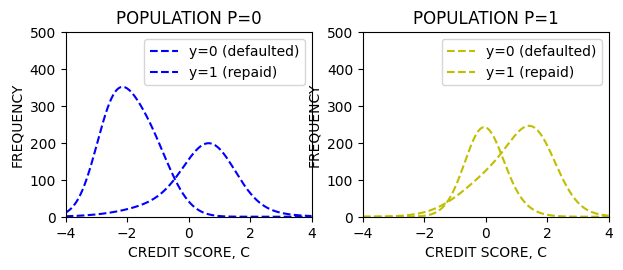

In [12]:
fig= plt.figure
ax= plt.subplot(2,2,1)
plt.tight_layout()
ax.plot(credit_scores, freq_y0_p0, 'b--', label='y=0 (defaulted)')
ax.plot(credit_scores, freq_y1_p0, 'b--', label='y=1 (repaid)')
ax.set_xlim(-4, 4)
ax.set_ylim(0, 500)
ax.set_xlabel('CREDIT SCORE, C')
ax.set_ylabel('FREQUENCY')
ax.set_title('POPULATION P=0')
ax.legend()

ax= plt.subplot(2,2,2)
plt.tight_layout()
ax.plot(credit_scores, freq_y0_p1, 'y--', label='y=0 (defaulted)')
ax.plot(credit_scores, freq_y1_p1, 'y--', label='y=1 (repaid)')
ax.set_xlim(-4, 4)
ax.set_ylim(0, 500)
ax.set_xlabel('CREDIT SCORE, C')
ax.set_ylabel('FREQUENCY')
ax.set_title('POPULATION P=1')
ax.legend()

plt.show()

####-----------------------------------------------------------------------------------------------------------------------

In [13]:
tau0= tau1= 0.0

In [16]:
def compute_probability_get_loan(credit_scores, frequencies, threshold):
  prob= 0.5
  return prob

In [17]:
pr_get_loan_p0= compute_probability_get_loan(credit_scores, freq_y0_p0+freq_y1_p0, tau0)
pr_get_loan_p1= compute_probability_get_loan(credit_scores, freq_y0_p1+freq_y1_p1, tau1)
print("PROBABILIDADES PARA O GRUPO AZUL = %3.3f"%(pr_get_loan_p0))
print("PROBABILIDADES PARA O GRUPO AMARELO = %3.3f"%(pr_get_loan_p1))

PROBABILIDADES PARA O GRUPO AZUL = 0.500
PROBABILIDADES PARA O GRUPO AMARELO = 0.500


In [25]:
def plot_roc(credit_scores, freq_y0_p0, freq_y1_p0, freq_y0_p1, freq_y1_p1, tau0, tau1):
  true_positives_p0 = np.zeros_like(credit_scores)
  false_alarms_p0 = np.zeros_like(credit_scores)
  true_positives_p1 = np.zeros_like(credit_scores)
  false_alarms_p1 = np.zeros_like(credit_scores)
  for i in range(len(credit_scores)):
    true_positives_p0[i] = compute_probability_get_loan(credit_scores, freq_y1_p0, credit_scores[i])
    true_positives_p1[i] = compute_probability_get_loan(credit_scores, freq_y1_p1, credit_scores[i])
    false_alarms_p0[i] = compute_probability_get_loan(credit_scores, freq_y0_p0, credit_scores[i])
    false_alarms_p1[i] = compute_probability_get_loan(credit_scores, freq_y0_p1, credit_scores[i])

  true_positives_p0_tau0 = compute_probability_get_loan(credit_scores, freq_y1_p0, tau0)
  true_positives_p1_tau1 = compute_probability_get_loan(credit_scores, freq_y1_p1, tau1)
  false_alarms_p0_tau0 = compute_probability_get_loan(credit_scores, freq_y0_p0, tau0)
  false_alarms_p1_tau1 = compute_probability_get_loan(credit_scores, freq_y0_p1, tau1)

  fig, ax = plt.subplots()
  ax.plot(false_alarms_p0, true_positives_p0, 'b-')
  ax.plot(false_alarms_p1, true_positives_p1, 'y-')
  ax.plot(false_alarms_p0_tau0, true_positives_p0_tau0,'bo')
  ax.plot(false_alarms_p1_tau1, true_positives_p1_tau1,'yo')
  ax.set_xlim(0,1)
  ax.set_ylim(0,1)
  ax.set_xlabel('False alarms')
  ax.set_ylabel('True positives')
  ax.set_aspect('equal')

  plt.show()

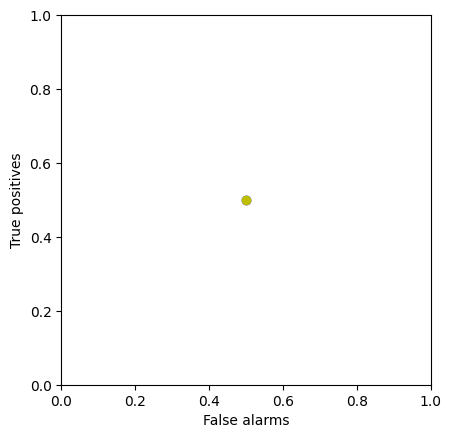

In [26]:
plot_roc(credit_scores, freq_y0_p0, freq_y1_p0, freq_y0_p1, freq_y1_p1, tau0, tau1)